# SDAHU: как понять, даёт ли окно дополнительную информацию

Этот ноутбук отвечает на вопрос:

> какого размера должно быть окно, чтобы оно давало **дополнительную информацию** относительно одной точки, а не просто дублировало соседние наблюдения.

Предположение для этого ноутбука:
- каждая траектория целиком принадлежит одному классу;
- значит нас не интересует смена label внутри окна;
- нас интересует **длина памяти процесса** и **избыточность соседних точек**.

Что считаем:
1. **Autocorrelation / ACF** по лагам — как долго точки остаются похожими.
2. **Lag threshold** — на каком лаге зависимость падает ниже порога.
3. **ESS ratio** — эффективное число независимых точек внутри траектории.
4. **Rolling-mean variance ratio** — насколько окно сглаживает сигнал.
5. **Mean delta / std ratio** — насколько соседние точки реально колеблются.

Практическая интерпретация:
- если автокорреляция падает очень быстро, большое окно вряд ли нужно;
- если она долго держится, история несёт дополнительную информацию;
- если rolling mean слишком быстро убивает дисперсию, окно становится слишком сглаженным.


In [1]:
import gc
import warnings
from os.path import join

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [2]:
# При необходимости поменяй путь на свой.
folder = r'/home/ilya_treyvish/projects/lbnl_fdd/data/processed/SDAHU'

train_df = pd.read_csv(join(folder, 'train_df.csv'), index_col=[0, 1], parse_dates=[1])
train_target = pd.read_csv(join(folder, 'train_target.csv'), index_col=[0, 1], parse_dates=[1])

print('train_df shape:', train_df.shape)
print('train_target shape:', train_target.shape)
train_df.head()


train_df shape: (4448700, 25)
train_target shape: (4448700, 1)


CHWC_VLV_DM  ZONE_TEMP_4    SA_CFM        SF_WAT    MA_TEMP  SYS_CTL  OA_DMPR_DM  ZONE_TEMP_2   RA_TEMP      CHWC_VLV  SF_CS  ZONE_TEMP_5  RF_SPD  OA_DMPR    OA_TEMP  \
fault_type Datetime                                                                                                                                                                                     
0          2018-01-01 01:00:00          0.0    66.761345 -0.943331 -2.791519e-13  66.374680      0.0         0.0    66.767230  68.34175  2.635303e-21    0.0    67.206566     0.0      0.0  10.355011   
           2018-01-01 01:01:00          0.0    66.761290 -0.943167 -2.790612e-13  66.374680      0.0         0.0    66.766680  68.34786  2.479578e-21    0.0    67.207720     0.0      0.0  10.040033   
           2018-01-01 01:02:00          0.0    66.761185 -0.943027 -2.789696e-13  66.374680      0.0         0.0    66.766014  68.35378  2.380361e-21    0.0    67.208760     0.0      0.0  10.055031   
           2018-01-01 01:03:00          0.0    66.761020 -0.942867 -2.788807e-13  66.374626      0.0         0.0    66.765305  68.35948 -1.274259e-21    0.0    67.209700     0.0      0.0  10.070026   
           2018-01-01 01:04:00          0.0    66.760740 -0.942719 -2.787895e-13  66.374626      0.0         0.0    66.764530  68.36498  2.749987e-21    0.0    67.210570     0.0      0.0  10.085022   

                                RA_DMPR_DM    SA_TEMP  RF_CS  RA_DMPR    RA_CFM  RF_SPD_DM        RF_WAT  ZONE_TEMP_1  ZONE_TEMP_3  SF_SPD_DM  
fault_type Datetime                                                                                                                            
0          2018-01-01 01:00:00         1.0  66.374680    0.0      1.0  0.853194        0.0 -2.617164e-13     73.94652    67.027100        0.0  
           2018-01-01 01:01:00         1.0  66.374680    0.0      1.0  0.853057        0.0 -2.616267e-13     73.97777    67.025894        0.0  
           2018-01-01 01:02:00         1.0  66.374680    0.0      1.0  0.852918        0.0 -2.615462e-13     74.00836    67.024580        0.0  
           2018-01-01 01:03:00         1.0  66.374626    0.0      1.0  0.852779        0.0 -2.614546e-13     74.03825    67.023150        0.0  
           2018-01-01 01:04:00         1.0  66.374626    0.0      1.0  0.852641        0.0 -2.613691e-13     74.06741    67.021670        0.0

In [3]:
def ensure_target_series(target: pd.DataFrame | pd.Series | np.ndarray) -> pd.Series:
    if isinstance(target, pd.Series):
        return target

    if isinstance(target, pd.DataFrame):
        if target.shape[1] != 1:
            raise ValueError(f'У target DataFrame {target.shape[1]} столбцов; ожидался 1 столбец.')
        return target.iloc[:, 0]

    arr = np.asarray(target)
    if arr.ndim == 2:
        if arr.shape[1] != 1:
            raise ValueError(f'target имеет shape={arr.shape}; ожидался shape (n,) или (n, 1).')
        arr = arr.reshape(-1)
    elif arr.ndim != 1:
        raise ValueError(f'target имеет ndim={arr.ndim}; ожидался 1D или 2D c одним столбцом.')

    return pd.Series(arr)


def prepare_grouped_arrays(df: pd.DataFrame, target) -> tuple[list, list]:
    x = df.copy().sort_index(level=['fault_type', 'Datetime'])
    y = ensure_target_series(target)

    if len(y) != len(x):
        raise ValueError(f'Длины df и target не совпадают: len(df)={len(x)}, len(target)={len(y)}')

    if isinstance(y.index, pd.MultiIndex) and y.index.equals(x.index):
        y_sorted = y.loc[x.index]
    else:
        y_sorted = pd.Series(np.asarray(y).reshape(-1), index=x.index)

    feature_names = [c for c in x.columns if pd.api.types.is_numeric_dtype(x[c])]

    groups = []
    for fault_value, g in x.groupby(level='fault_type', sort=False):
        g_idx = g.index
        Xg = g[feature_names].to_numpy(dtype=np.float32)
        yg = y_sorted.loc[g_idx].to_numpy().reshape(-1)

        groups.append({
            'fault_type': fault_value,
            'X': Xg,
            'y': yg,
            'index': g_idx,
        })

    return groups, feature_names


train_groups, feature_names = prepare_grouped_arrays(train_df, train_target)
train_target_s = ensure_target_series(train_target)
if isinstance(train_target_s.index, pd.MultiIndex):
    train_target_s = train_target_s.sort_index(level=['fault_type', 'Datetime'])

classes_ = np.sort(pd.unique(train_target_s.to_numpy().reshape(-1)))

print('n_groups:', len(train_groups))
print('n_features:', len(feature_names))
print('classes_:', classes_)
print('example group X shape:', train_groups[0]['X'].shape)


n_groups: 15
n_features: 25
classes_: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
example group X shape: (305220, 25)


## Базовая идея анализа

Мы хотим понять, сколько шагов назад история ещё содержит информацию.

Для этого ниже будут 3 главные семейства метрик:

- **ACF**: как быстро затухает похожесть `x[t]` и `x[t+lag]`;
- **lag-to-threshold**: минимальный лаг, где средняя автокорреляция падает ниже порога;
- **window smoothing**: насколько скользящее окно уменьшает вариативность.

Хороший `window_size` обычно лежит в диапазоне:
- уже больше, чем совсем локальный шум;
- но ещё не настолько велик, что окно почти полностью сглаживает динамику.


In [4]:
ANALYSIS_FEATURES = feature_names.copy()  # можно вручную сократить список
MAX_LAG = 200
WINDOW_GRID = [1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200, 1000]
MIN_TRAJ_LEN = 30
EPS = 1e-12

print('Будем анализировать', len(ANALYSIS_FEATURES), 'фичей')


Будем анализировать 25 фичей


In [5]:
def standardize_1d(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd < EPS:
        return np.zeros_like(x, dtype=np.float64)
    return (x - mu) / sd


def autocorr_1d(x: np.ndarray, max_lag: int) -> np.ndarray:
    x = standardize_1d(x)
    n = len(x)
    if n < 2:
        return np.full(max_lag + 1, np.nan, dtype=np.float64)

    out = np.empty(max_lag + 1, dtype=np.float64)
    out[0] = 1.0
    for lag in range(1, max_lag + 1):
        if lag >= n:
            out[lag] = np.nan
            continue
        x1 = x[:-lag]
        x2 = x[lag:]
        if len(x1) < 2:
            out[lag] = np.nan
            continue
        out[lag] = np.mean(x1 * x2)
    return out


def first_lag_below_threshold(acf: np.ndarray, threshold: float) -> float:
    valid = np.where(np.isfinite(acf))[0]
    valid = valid[valid > 0]
    if len(valid) == 0:
        return np.nan
    below = valid[acf[valid] < threshold]
    if len(below) == 0:
        return np.nan
    return float(below[0])


def effective_sample_size_ratio(acf: np.ndarray) -> float:
    valid = np.where(np.isfinite(acf))[0]
    valid = valid[valid > 0]
    if len(valid) == 0:
        return np.nan

    positive_prefix = []
    for i in valid:
        if acf[i] <= 0:
            break
        positive_prefix.append(acf[i])

    if len(positive_prefix) == 0:
        tau = 1.0
    else:
        tau = 1.0 + 2.0 * np.sum(positive_prefix)

    return 1.0 / tau


def rolling_mean_variance_ratio(x: np.ndarray, window: int) -> float:
    x = np.asarray(x, dtype=np.float64)
    if len(x) < window or window <= 0:
        return np.nan
    base_var = np.nanvar(x)
    if not np.isfinite(base_var) or base_var < EPS:
        return np.nan
    rolled = pd.Series(x).rolling(window=window).mean().dropna().to_numpy()
    if len(rolled) == 0:
        return np.nan
    return float(np.nanvar(rolled) / base_var)


def mean_abs_delta_ratio(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    if len(x) < 2:
        return np.nan
    sd = np.nanstd(x)
    if not np.isfinite(sd) or sd < EPS:
        return np.nan
    return float(np.nanmean(np.abs(np.diff(x))) / sd)


In [6]:
def collect_feature_dynamics(groups, feature_names, max_lag=200, min_traj_len=30, window_grid=None):
    if window_grid is None:
        window_grid = [1, 2, 5, 10, 20, 50, 100]

    feature_to_idx = {f: i for i, f in enumerate(feature_names)}
    acf_rows = []
    summary_rows = []
    window_rows = []

    for group in tqdm(groups, desc='groups'):
        Xg = group['X']
        yg = group['y']
        traj_class = yg[0]
        traj_len = len(Xg)
        if traj_len < max(2, min_traj_len):
            continue

        for feature in feature_names:
            col_idx = feature_to_idx[feature]
            x = Xg[:, col_idx].astype(np.float64)
            if np.all(~np.isfinite(x)):
                continue
            if np.nanstd(x) < EPS:
                continue

            acf = autocorr_1d(x, max_lag=min(max_lag, traj_len - 1))
            ess_ratio = effective_sample_size_ratio(acf)
            lag_05 = first_lag_below_threshold(acf, 0.5)
            lag_02 = first_lag_below_threshold(acf, 0.2)
            lag_01 = first_lag_below_threshold(acf, 0.1)
            delta_ratio = mean_abs_delta_ratio(x)

            summary_rows.append({
                'fault_type': group['fault_type'],
                'class': traj_class,
                'traj_len': traj_len,
                'feature': feature,
                'ess_ratio': ess_ratio,
                'lag_below_0_5': lag_05,
                'lag_below_0_2': lag_02,
                'lag_below_0_1': lag_01,
                'delta_ratio': delta_ratio,
            })

            for lag in range(len(acf)):
                acf_rows.append({
                    'fault_type': group['fault_type'],
                    'class': traj_class,
                    'traj_len': traj_len,
                    'feature': feature,
                    'lag': lag,
                    'acf': acf[lag],
                })

            for w in window_grid:
                ratio = rolling_mean_variance_ratio(x, window=w)
                window_rows.append({
                    'fault_type': group['fault_type'],
                    'class': traj_class,
                    'traj_len': traj_len,
                    'feature': feature,
                    'window': w,
                    'rolling_var_ratio': ratio,
                })

    acf_df = pd.DataFrame(acf_rows)
    summary_df = pd.DataFrame(summary_rows)
    window_df = pd.DataFrame(window_rows)
    return acf_df, summary_df, window_df


In [7]:
acf_df, dynamics_summary_df, window_var_df = collect_feature_dynamics(
    groups=train_groups,
    feature_names=ANALYSIS_FEATURES,
    max_lag=MAX_LAG,
    min_traj_len=MIN_TRAJ_LEN,
    window_grid=WINDOW_GRID,
)

print('acf_df shape:', acf_df.shape)
print('dynamics_summary_df shape:', dynamics_summary_df.shape)
print('window_var_df shape:', window_var_df.shape)

dynamics_summary_df.head()


groups:   0%|          | 0/15 [00:00<?, ?it/s]

acf_df shape: (72963, 6)
dynamics_summary_df shape: (363, 9)
window_var_df shape: (4356, 6)


,fault_type,class,traj_len,feature,ess_ratio,lag_below_0_5,lag_below_0_2,lag_below_0_1,delta_ratio
0,0,0,305220,CHWC_VLV_DM,0.003203,NaN,NaN,NaN,0.003891
1,0,0,305220,ZONE_TEMP_4,0.002779,NaN,NaN,NaN,0.003118
2,0,0,305220,SA_CFM,0.003177,NaN,NaN,NaN,0.004035
3,0,0,305220,SF_WAT,0.003633,170.0,NaN,NaN,0.004417
4,0,0,305220,MA_TEMP,0.002710,NaN,NaN,NaN,0.002125


## Сводка по всем траекториям и фичам

Ниже агрегируем по фичам и траекториям. Это первая грубая оценка, какого размера окно может быть осмысленным.

Ориентиры:
- `lag_below_0_5` — где сильная связь уже заметно ослабла;
- `lag_below_0_2` — где остаётся только умеренная память;
- `lag_below_0_1` — где память почти исчезла;
- `ess_ratio` — какая доля точек ведёт себя как реально независимые.


In [8]:
overall_summary = (
    dynamics_summary_df
    .agg({
        'ess_ratio': ['median', 'mean'],
        'lag_below_0_5': ['median', 'mean'],
        'lag_below_0_2': ['median', 'mean'],
        'lag_below_0_1': ['median', 'mean'],
        'delta_ratio': ['median', 'mean'],
    })
)
overall_summary


,ess_ratio,lag_below_0_5,lag_below_0_2,lag_below_0_1,delta_ratio
median,0.003293,187.000000,12.0,14.0,0.004088
mean,0.003442,176.719697,12.0,14.0,0.004729


In [9]:
per_class_summary = (
    dynamics_summary_df
    .groupby('class', dropna=False)
    .agg(
        n_feature_traj=('feature', 'count'),
        ess_ratio_median=('ess_ratio', 'median'),
        ess_ratio_mean=('ess_ratio', 'mean'),
        lag05_median=('lag_below_0_5', 'median'),
        lag02_median=('lag_below_0_2', 'median'),
        lag01_median=('lag_below_0_1', 'median'),
        delta_ratio_median=('delta_ratio', 'median'),
    )
    .sort_values('lag02_median', ascending=False)
)
per_class_summary


,n_feature_traj,ess_ratio_median,ess_ratio_mean,lag05_median,lag02_median,lag01_median,delta_ratio_median
class,,,,,,,
9,24,0.003396,0.005820,182.0,12.0,14.0,0.003879
0,25,0.003203,0.003141,161.5,NaN,NaN,0.003307
1,25,0.003343,0.003240,190.5,NaN,NaN,0.004550
2,25,0.003426,0.003332,180.0,NaN,NaN,0.005777
3,25,0.003391,0.003329,193.5,NaN,NaN,0.004076
4,25,0.003393,0.003399,191.0,NaN,NaN,0.003833
5,25,0.003279,0.003262,194.0,NaN,NaN,0.004072
6,24,0.003051,0.003051,178.0,NaN,NaN,0.005381
7,24,0.003373,0.003249,189.0,NaN,NaN,0.006211


In [10]:
per_feature_summary = (
    dynamics_summary_df
    .groupby('feature', dropna=False)
    .agg(
        n_traj=('fault_type', 'count'),
        ess_ratio_median=('ess_ratio', 'median'),
        lag05_median=('lag_below_0_5', 'median'),
        lag02_median=('lag_below_0_2', 'median'),
        lag01_median=('lag_below_0_1', 'median'),
        delta_ratio_median=('delta_ratio', 'median'),
    )
    .sort_values('lag02_median', ascending=False)
)
per_feature_summary.head(20)


,n_traj,ess_ratio_median,lag05_median,lag02_median,lag01_median,delta_ratio_median
feature,,,,,,
CHWC_VLV_DM,15,0.003265,8.0,12.0,14.0,0.004290
CHWC_VLV,11,0.003258,NaN,NaN,NaN,0.004075
MA_TEMP,15,0.002704,NaN,NaN,NaN,0.002611
OA_DMPR,11,0.003396,189.0,NaN,NaN,0.003437
OA_DMPR_DM,15,0.003396,178.0,NaN,NaN,0.003415
OA_TEMP,15,0.002526,NaN,NaN,NaN,0.001190
RA_CFM,15,0.003434,192.0,NaN,NaN,0.004609
RA_DMPR,11,0.003393,183.5,NaN,NaN,0.003386
RA_DMPR_DM,15,0.003396,178.0,NaN,NaN,0.003415


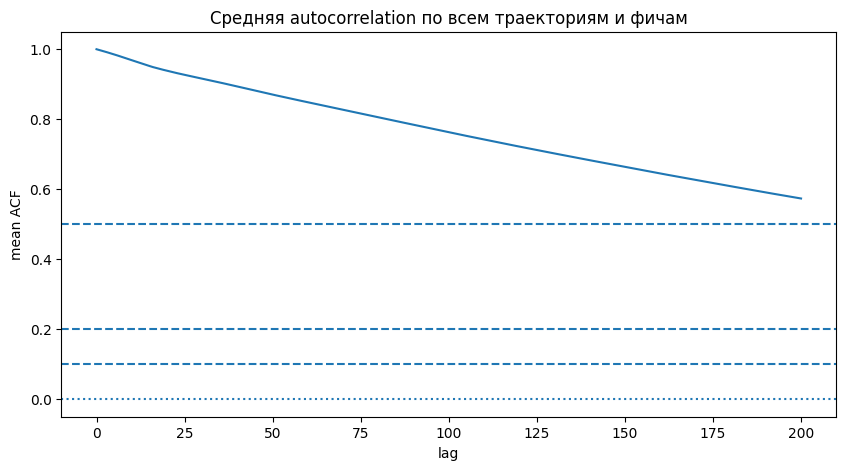

In [11]:
acf_mean_by_lag = (
    acf_df.groupby('lag', as_index=False)['acf']
    .mean()
    .sort_values('lag')
)

plt.figure(figsize=(10, 5))
plt.plot(acf_mean_by_lag['lag'], acf_mean_by_lag['acf'])
plt.axhline(0.5, linestyle='--')
plt.axhline(0.2, linestyle='--')
plt.axhline(0.1, linestyle='--')
plt.axhline(0.0, linestyle=':')
plt.xlabel('lag')
plt.ylabel('mean ACF')
plt.title('Средняя autocorrelation по всем траекториям и фичам')
plt.show()


In [12]:
window_ratio_summary = (
    window_var_df
    .groupby('window', as_index=False)
    .agg(
        rolling_var_ratio_median=('rolling_var_ratio', 'median'),
        rolling_var_ratio_mean=('rolling_var_ratio', 'mean'),
    )
    .sort_values('window')
)
window_ratio_summary


,window,rolling_var_ratio_median,rolling_var_ratio_mean
0,1,1.000000,1.000000
1,2,0.998835,0.998596
2,5,0.996270,0.995421
3,10,0.992307,0.990229
4,20,0.983328,0.979478
5,30,0.973015,0.969327
6,50,0.953783,0.951465
7,75,0.931894,0.931018
8,100,0.910181,0.911561
9,150,0.870733,0.874282


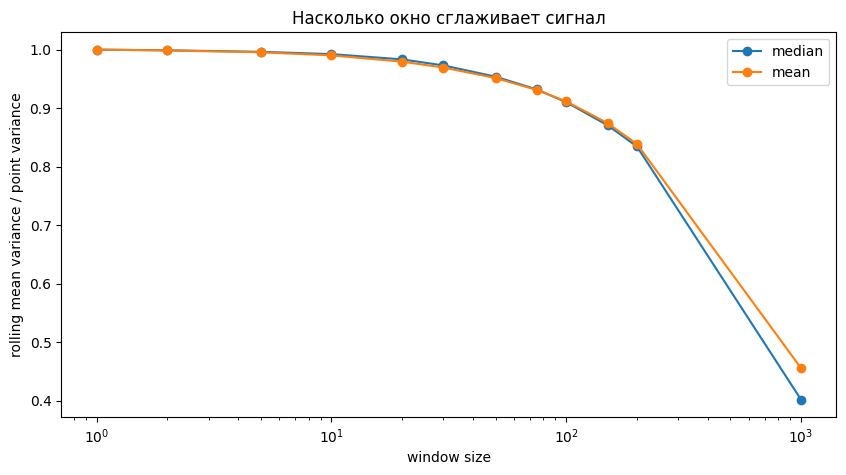

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(window_ratio_summary['window'], window_ratio_summary['rolling_var_ratio_median'], marker='o', label='median')
plt.plot(window_ratio_summary['window'], window_ratio_summary['rolling_var_ratio_mean'], marker='o', label='mean')
plt.xscale('log')
plt.xlabel('window size')
plt.ylabel('rolling mean variance / point variance')
plt.title('Насколько окно сглаживает сигнал')
plt.legend()
plt.show()


## Автоматическая рекомендация по окну

Это не строгая истина, а эвристика.

Возьмём три ориентира:
- `recommended_min_window` ≈ медианный лаг, где ACF падает ниже `0.5`;
- `recommended_mid_window` ≈ медианный лаг, где ACF падает ниже `0.2`;
- `recommended_max_window` ≈ медианный лаг, где ACF падает ниже `0.1`.

Идея:
- меньше `recommended_min_window` — окно, скорее всего, ещё слишком локальное;
- около `recommended_mid_window` — часто разумный компромисс;
- больше `recommended_max_window` — окно часто уже начинает быть избыточно сглаженным.


In [14]:
recommendation = pd.DataFrame([
    {
        'recommended_min_window': float(np.nanmedian(dynamics_summary_df['lag_below_0_5'])),
        'recommended_mid_window': float(np.nanmedian(dynamics_summary_df['lag_below_0_2'])),
        'recommended_max_window': float(np.nanmedian(dynamics_summary_df['lag_below_0_1'])),
        'ess_ratio_median': float(np.nanmedian(dynamics_summary_df['ess_ratio'])),
        'delta_ratio_median': float(np.nanmedian(dynamics_summary_df['delta_ratio'])),
    }
])
recommendation


,recommended_min_window,recommended_mid_window,recommended_max_window,ess_ratio_median,delta_ratio_median
0,187.0,12.0,14.0,0.003293,0.004088


In [15]:
def interpret_window_recommendation(rec_df, window_ratio_summary):
    rec = rec_df.iloc[0].to_dict()
    smooth_50 = window_ratio_summary.loc[
        (window_ratio_summary['rolling_var_ratio_median'] <= 0.5), 'window'
    ]
    smooth_25 = window_ratio_summary.loc[
        (window_ratio_summary['rolling_var_ratio_median'] <= 0.25), 'window'
    ]

    result = {
        'acf_based_min': rec['recommended_min_window'],
        'acf_based_mid': rec['recommended_mid_window'],
        'acf_based_max': rec['recommended_max_window'],
        'first_window_var_ratio_le_0_50': float(smooth_50.iloc[0]) if len(smooth_50) else np.nan,
        'first_window_var_ratio_le_0_25': float(smooth_25.iloc[0]) if len(smooth_25) else np.nan,
    }
    return pd.DataFrame([result])

interpret_window_recommendation(recommendation, window_ratio_summary)


,acf_based_min,acf_based_mid,acf_based_max,first_window_var_ratio_le_0_50,first_window_var_ratio_le_0_25
0,187.0,12.0,14.0,1000.0,NaN


## Посмотреть отдельные фичи

Обычно полезно проверить несколько самых важных признаков руками. Ниже можно выбрать одну фичу и посмотреть её ACF и сглаживание.


In [16]:
FEATURE_TO_PLOT = per_feature_summary.index[0] if len(per_feature_summary) else ANALYSIS_FEATURES[0]
FEATURE_TO_PLOT


'CHWC_VLV_DM'

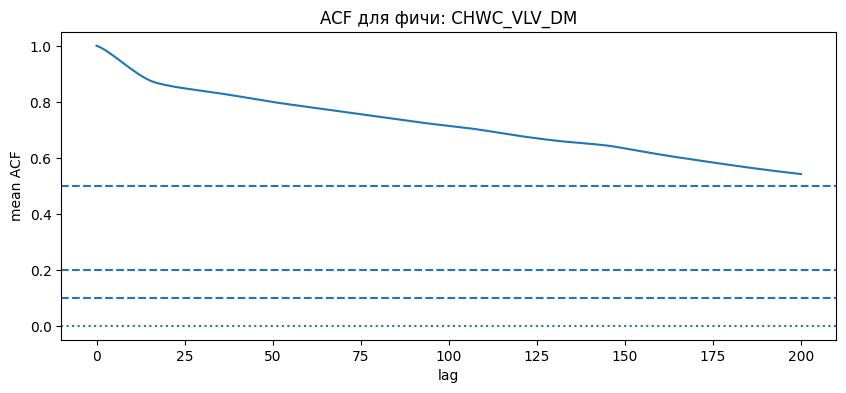

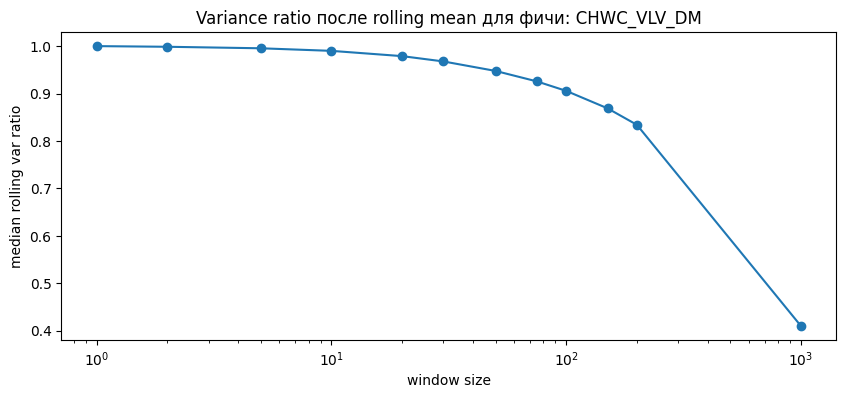

In [17]:
feature_acf = (
    acf_df[acf_df['feature'] == FEATURE_TO_PLOT]
    .groupby('lag', as_index=False)['acf']
    .mean()
    .sort_values('lag')
)

feature_window_ratio = (
    window_var_df[window_var_df['feature'] == FEATURE_TO_PLOT]
    .groupby('window', as_index=False)['rolling_var_ratio']
    .median()
    .sort_values('window')
)

plt.figure(figsize=(10, 4))
plt.plot(feature_acf['lag'], feature_acf['acf'])
plt.axhline(0.5, linestyle='--')
plt.axhline(0.2, linestyle='--')
plt.axhline(0.1, linestyle='--')
plt.axhline(0.0, linestyle=':')
plt.title(f'ACF для фичи: {FEATURE_TO_PLOT}')
plt.xlabel('lag')
plt.ylabel('mean ACF')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(feature_window_ratio['window'], feature_window_ratio['rolling_var_ratio'], marker='o')
plt.xscale('log')
plt.title(f'Variance ratio после rolling mean для фичи: {FEATURE_TO_PLOT}')
plt.xlabel('window size')
plt.ylabel('median rolling var ratio')
plt.show()


## Как интерпретировать результат

Практическое правило для выбора окна:

1. Сначала посмотри на `recommended_mid_window`.
   - это хороший первый кандидат на `window_size`.

2. Затем проверь `first_window_var_ratio_le_0_50`.
   - если это значение заметно меньше `recommended_mid_window`, значит окно быстро сглаживает сигнал;
   - тогда лучше брать окно ближе к нижней границе.

3. Если моделью ты уже гонял `window=1`, `10`, `100`, то сопоставь:
   - попадает ли `10` в область, где ACF ещё держится;
   - не лежит ли `100` уже далеко за лагом, где память почти исчезла.

4. Если разные фичи ведут себя по-разному:
   - можно брать окно по медиане важных фич;
   - или оставить большое окно, но сделать `sparse_step`, чтобы не тащить слишком много избыточных точек.


In [18]:
# При желании сохраним артефакты анализа.
artifacts_dir = join('/home/ilya_treyvish/projects/lbnl_fdd/data', 'artifacts_window_info_analysis')
# Раскомментируй, если хочешь сохранять результаты на диск.
# import os
# os.makedirs(artifacts_dir, exist_ok=True)
# acf_df.to_csv(join(artifacts_dir, 'acf_df.csv'), index=False)
# dynamics_summary_df.to_csv(join(artifacts_dir, 'dynamics_summary_df.csv'), index=False)
# window_var_df.to_csv(join(artifacts_dir, 'window_var_df.csv'), index=False)
# per_class_summary.to_csv(join(artifacts_dir, 'per_class_summary.csv'))
# per_feature_summary.to_csv(join(artifacts_dir, 'per_feature_summary.csv'))
# recommendation.to_csv(join(artifacts_dir, 'window_recommendation.csv'), index=False)
